# Environment Setup

In [60]:
# Cell: Environment Repair — run at top of notebook, then RESTART the runtime
%pip uninstall -y numpy scipy gensim node2vec networkx
%pip install numpy==1.26.4 scipy==1.13.1 gensim==4.3.3
%pip install node2vec==0.5.0 networkx==3.4.2

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
Found existing installation: gensim 4.3.3
Uninstalling gensim-4.3.3:
  Successfully uninstalled gensim-4.3.3
Found existing installation: node2vec 0.5.0
Uninstalling node2vec-0.5.0:
  Successfully uninstalled node2vec-0.5.0
Found existing installation: networkx 3.4.2
Uninstalling networkx-3.4.2:
  Successfully uninstalled networkx-3.4.2
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached scipy-1.13.1-cp311-cp3

  Using cached node2vec-0.5.0-py3-none-any.whl.metadata (849 bytes)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
Using cached node2vec-0.5.0-py3-none-any.whl (7.2 kB)
Using cached networkx-3.4.2-py3-none-any.whl (1.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-nvrtc-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requir

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import numpy as np
import gensim
from node2vec import Node2Vec

In [2]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive/MyDrive/tesi_tirabassi/

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive/MyDrive/tesi_tirabassi


In [3]:
import os
import random
import warnings
import logging

# reproducibility
seed = 42
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# suppress TF/C logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.simplefilter('ignore')
logging.getLogger('matplotlib').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# plotting defaults
np.random.seed(seed)
sns.set_style('white')
sns.set_context('talk', font_scale=1.2)
plt.rc('figure', figsize=(8,6))
%matplotlib inline

# Data Load

Load and stack all matrices vertically

In [4]:
from glob import glob

# Point to your folder of CSV files
A_FOLDER  = 'A_matrices'
csv_paths = sorted(glob(f'{A_FOLDER}/*_A.csv'))

# Debug: ensure files are found
if not csv_paths:
    raise FileNotFoundError(f"No files matched {A_FOLDER}/*_A.csv")

# Load each matrix (no headers)
A_dfs = [pd.read_csv(fp, header=None) for fp in csv_paths]

# Stack vertically: shape = (n_subjects * n_rois, n_rois)
stacked_A = pd.concat(A_dfs, ignore_index=True)
print(f"Loaded {len(A_dfs)} matrices → stacked_A shape: {stacked_A.shape}")

Loaded 20 matrices → stacked_A shape: (1480, 74)


## Brain Region Names

In [5]:
import pandas as pd

# 1) Load only the columns we need
df = pd.read_excel(
    'rois_id_acr_names.xlsx',
    usecols=['ID', 'ACRO', 'NAME', 'ID.1']
)

# 2) Drop any placeholder or totally empty rows (here, NAME is NaN for the one “MISSING” row)
df = df.dropna(subset=['ACRO', 'NAME'])

# 3) Split into left vs. right hemisphere entries
#    - 'ID' is the atlas ID for left; 'ID.1' is for right
left = df[['ID', 'ACRO', 'NAME']].copy()
right = df[['ID.1', 'ACRO', 'NAME']].copy().rename(columns={'ID.1': 'ID'})

# 4) Concatenate → 37 left + 37 right = 74 total
full_rois = pd.concat([left, right], ignore_index=True)

# 5) Sort by the atlas ID if you like (optional) and then reset the index
#    Resetting the index gives us a clean 0…73 roi_index that matches your matrix rows
full_rois = (
    full_rois
      .sort_values('ID')      # optional, only if your matrices were generated in this ID order
      .reset_index(drop=True)
      .reset_index()
      .rename(columns={'index':'roi_index'})
)

# 6) Check we now have exactly 74 ROIs
n_rois = A_dfs[0].shape[0]
assert len(full_rois) == n_rois, f"Expected {n_rois} ROIs but found {len(full_rois)}"

## Single Matrix EDA

A0 5–95% range: -0.055 to 0.106


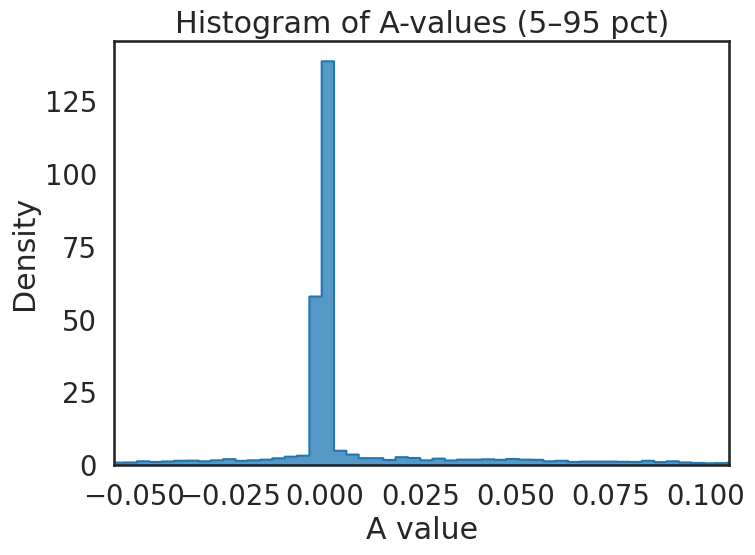

In [ ]:
# Select the first subject’s matrix
A0 = A_dfs[0].values  # shape (n_rois, n_rois)

# Compute 5th/95th percentiles to trim outliers
vmin, vmax = np.percentile(A0, [5, 95])
print(f"A0 5–95% range: {vmin:.3f} to {vmax:.3f}")

# ---- Histogram ----
plt.figure()
sns.histplot(
    A0.flatten(),
    binwidth=(vmax - vmin) / 50,
    stat='density',
    element='step',
)
plt.xlim(vmin, vmax)
plt.title('Histogram of A-values (5–95 pct)')
plt.xlabel('A value'); plt.ylabel('Density')
plt.tight_layout()
plt.show()

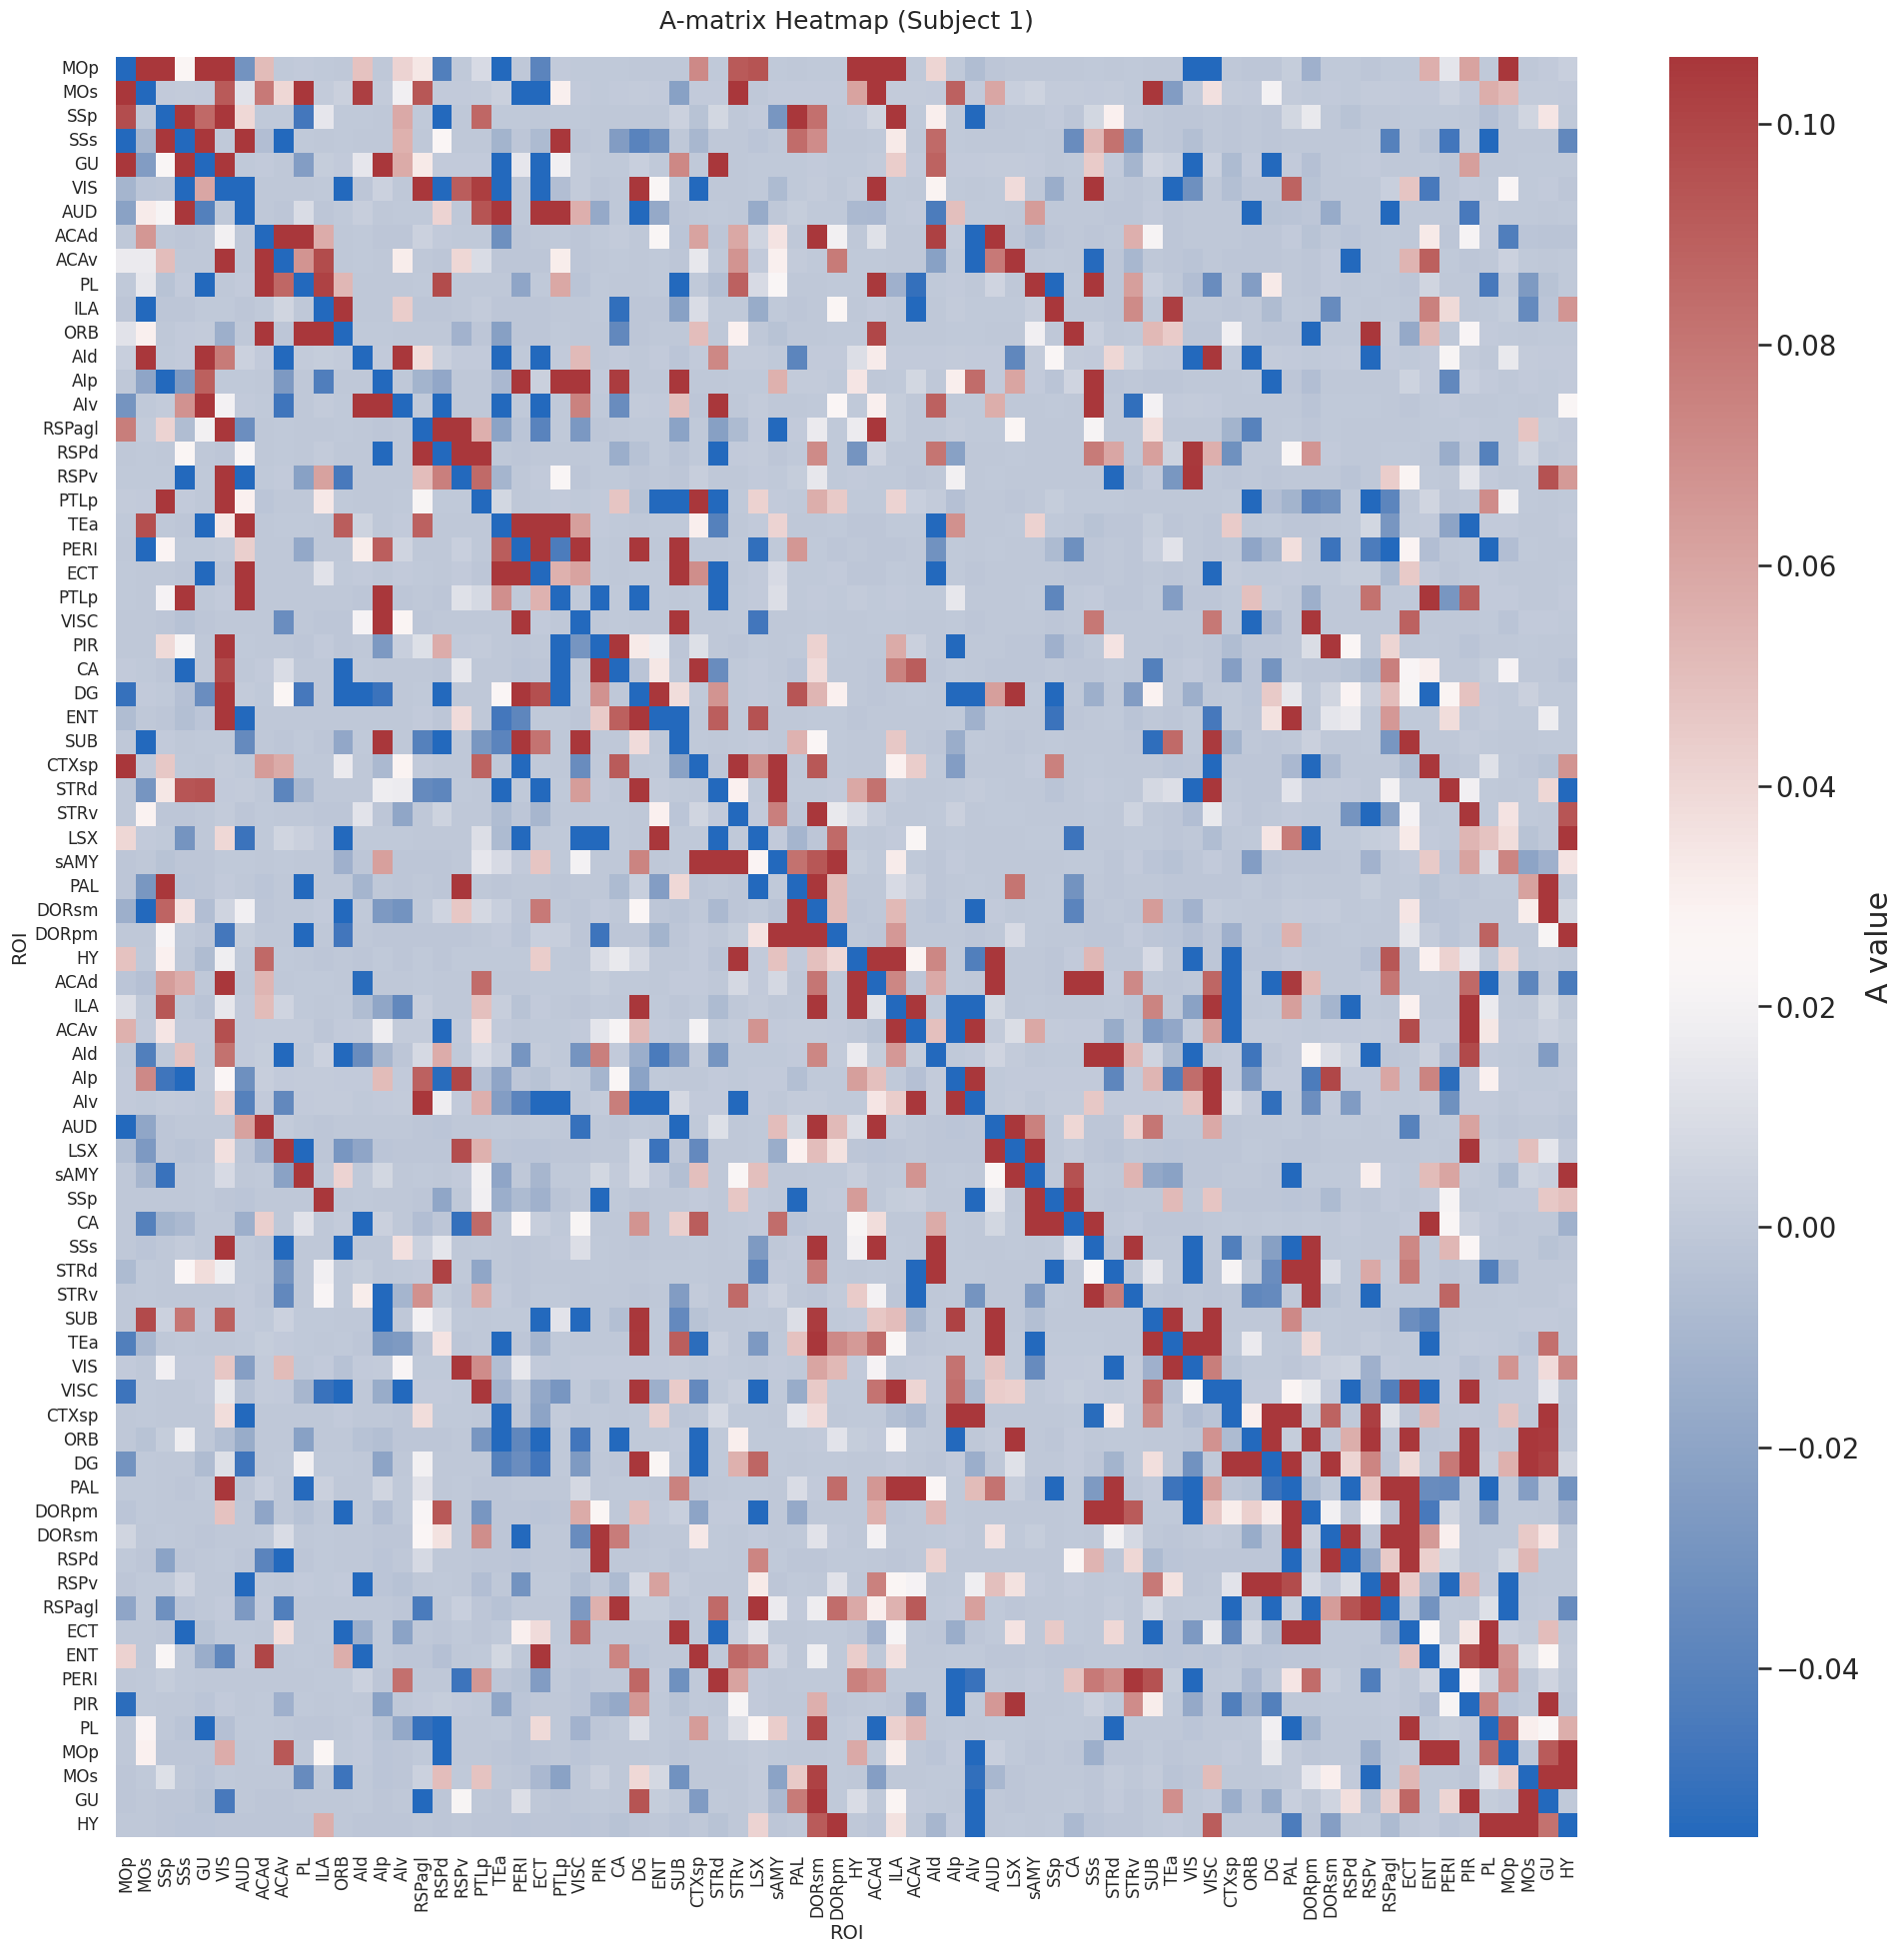

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Your ordered list of acronyms:
acro_labels = full_rois.sort_values('roi_index')['ACRO'].tolist()

plt.figure(figsize=(20,20))               # big canvas
ax = sns.heatmap(
    A0,
    vmin=vmin, vmax=vmax,
    cmap='vlag',
    cbar_kws={'label':'A value'},
    xticklabels=acro_labels,
    yticklabels=acro_labels
)

# Rotate and increase font size
ax.set_xticklabels(acro_labels, rotation=90, fontsize=12)
ax.set_yticklabels(acro_labels, rotation=0, fontsize=12)

ax.set_title('A-matrix Heatmap (Subject 1)', pad=20, fontsize=18)
ax.set_xlabel('ROI', fontsize=14)
ax.set_ylabel('ROI', fontsize=14)

plt.tight_layout()
plt.show()

# Node Embeddings

## Single Subj Directed Node2Vec

Taking an nxn effective-connectivity matrix, turning it into a directed graph, then using Node2Vec to run biased random walks on that graph. Those walks become sentences fed into a skip-gram Word2Vec model, yielding a 3-dimensional embedding for each parcellation.

Parcellations that co-occur of paths through the network (having similar effective connectviity neighborhoods) end up close together in Euclidean space, revealing clusters of similarly connected brain regions

Using NetworkX’s from_numpy_array to convert the NumPy array A0 into a graph object. Entry (i,j) in A0 becomes a directed edge from node ii to node jj with weight A0[i,j].

In [ ]:
import networkx as nx
from node2vec import Node2Vec

# 1. Build directed graph from adjacency A0
G = nx.from_numpy_array(A0, create_using=nx.DiGraph())  # respects directionality :contentReference[oaicite:1]{index=1}

From each node 200 walks, each of length 30. These walks sample the local network topology around every node.

Nodes appearing near each other ona  walk are analogous to words appearing in the same context.

Word2Vec pushes embeddings so that nodes with overlapping neighborhoods have similar vectors.

In [ ]:
# 2. Configure & train Node2Vec
n2v = Node2Vec(
    graph=G,
    dimensions=3,
    walk_length=30,
    num_walks=200,
    p=1, q=1,
    workers=4,
    seed=seed
)
model_n2v = n2v.fit(window=5, min_count=1, sg=1, epochs=50)

Computing transition probabilities:   0%|          | 0/74 [00:00<?, ?it/s]

In [ ]:
# 3. Extract 3D embeddings into a DataFrame
emb_dict = {
    int(node): model_n2v.wv[str(node)]
    for node in G.nodes()
}
embed_df = pd.DataFrame.from_dict(
    emb_dict, orient='index', columns=['X','Y','Z']
).reset_index().rename(columns={'index':'roi_index'})

Nodes that are frequently connected through similar routes (e.g. sensory areas) end up nearby in the 3D embedding, revealing functional modules or hierarchies.

The context of a node is biased toward its successors, i.e. regions it influences. In a directed graph, two nodes with similar outgoing neighborhoods (both projecting to the same set of target nodes) will end up closer together in embedding space, because their random-walk contexts overlap.

Directionality is implicitly encoded in who co-occurs where on walks, not as a vector arrows in the embedding.

In the following plot, using color scales to see which nodes act as sources (high out-degree) versus sinks (high in-degree) of directed influence.

In [ ]:
import plotly.express as px

# 1) Re-merge labels if necessary
embed_df = (
    embed_df
    .merge(full_rois[['roi_index','ACRO','NAME']],
           on='roi_index', how='left')
    .rename(columns={'ACRO':'roi_acro','NAME':'roi_name'})
)

# 2) (Re)compute degrees if you want to color by out-degree
embed_df['in_deg']  = [G.in_degree(i,  weight='weight')  for i in embed_df['roi_index']]
embed_df['out_deg'] = [G.out_degree(i, weight='weight')  for i in embed_df['roi_index']]

# 3) Call px.scatter_3d with only column names (no Series objects)
fig = px.scatter_3d(
    embed_df,
    x='X', y='Y', z='Z',
    text='roi_acro',                     # column name for static labels
    hover_data=['roi_name','in_deg','out_deg'],  # list of extra cols to show on hover
    color='out_deg',
    title='3D Node2Vec Embedding of ROIs (acronyms shown)',
    width=900, height=700,
    opacity=0.8
)

# 4) Position & style text labels
fig.update_traces(
    marker=dict(size=6, line=dict(width=0.5, color='DarkSlateGrey')),
    textposition='top center',
    textfont=dict(size=10, color='black')
)

# 5) Tidy up axes
fig.update_layout(
    legend_title_text='Out-degree',
    scene=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        xaxis=dict(backgroundcolor='rgb(230,230,230)'),
        yaxis=dict(backgroundcolor='rgb(230,230,230)'),
        zaxis=dict(backgroundcolor='rgb(230,230,230)')
    )
)

fig.show()

## All Subj Directed Node2Vec

In [6]:
import os
import numpy as np
import pandas as pd
import networkx as nx
from node2vec import Node2Vec
from glob import glob

# reproducibility
seed = 42
np.random.seed(seed)

# 1) Get all subject A‐matrices
A_paths = sorted(glob('A_matrices/*_A.csv'))
assert len(A_paths) == 20, f"Expected 20 subjects, got {len(A_paths)}"

# 2) Container for each subject’s embeddings
all_embs = []

for subj_idx, path in enumerate(A_paths, start=1):
    # a) Load adjacency
    A = pd.read_csv(path, header=None).values

    # b) Build directed graph
    G = nx.from_numpy_array(A, create_using=nx.DiGraph())  # preserves directionality :contentReference[oaicite:0]{index=0}

    # c) Node2Vec on this subject
    n2v = Node2Vec(
        graph=G,
        dimensions=3,
        walk_length=30,
        num_walks=200,
        p=1, q=1,
        workers=4,
        seed=seed
    )
    model = n2v.fit(window=5, min_count=1, sg=1, epochs=50)  # skip-gram

    # d) Extract embeddings
    emb_dict = {int(node): model.wv[str(node)] for node in G.nodes()}
    df_emb = (
        pd.DataFrame.from_dict(emb_dict, orient='index', columns=['X','Y','Z'])
          .reset_index().rename(columns={'index':'roi_index'})
    )
    df_emb['subject'] = subj_idx
    all_embs.append(df_emb)

# 3) Concatenate into one DataFrame
embeddings_all = pd.concat(all_embs, ignore_index=True)
print("Combined embeddings shape:", embeddings_all.shape)

Computing transition probabilities:   0%|          | 0/74 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/74 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/74 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/74 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/74 [00:00<?, ?it/s]

...

Computing transition probabilities:   0%|          | 0/74 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/74 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/74 [00:00<?, ?it/s]

Computing transition probabilities:   0%|          | 0/74 [00:00<?, ?it/s]

Combined embeddings shape: (1480, 5)


### Averaged Embeddings Across Subjects

In [8]:
# --- AVERAGE embeddings correctly ---
import numpy as np
import pandas as pd

# 1. Group by 'roi_index' and average over subjects
averaged = (
    embeddings_all
    .groupby('roi_index')[['X','Y','Z']]
    .mean()
    .reset_index()
)

embed_df = averaged.copy()

# --- VISUALIZE (your same exact plotting code) ---
embed_df = (
    embed_df
    .merge(full_rois[['roi_index','ACRO','NAME']],
           on='roi_index', how='left')
    .rename(columns={'ACRO':'roi_acro','NAME':'roi_name'})
)

embed_df['in_deg']  = [G.in_degree(i,  weight='weight')  for i in embed_df['roi_index']]
embed_df['out_deg'] = [G.out_degree(i, weight='weight')  for i in embed_df['roi_index']]

import plotly.express as px

fig = px.scatter_3d(
    embed_df,
    x='X', y='Y', z='Z',
    text='roi_acro',
    hover_data=['roi_name','in_deg','out_deg'],
    color='out_deg',
    title='3D Node2Vec Embedding of ROIs (averaged across subjects)',
    width=900, height=700,
    opacity=0.8
)

fig.update_traces(
    marker=dict(size=6, line=dict(width=0.5, color='DarkSlateGrey')),
    textposition='top center',
    textfont=dict(size=10, color='black')
)

fig.update_layout(
    legend_title_text='Out-degree',
    scene=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        xaxis=dict(backgroundcolor='rgb(230,230,230)'),
        yaxis=dict(backgroundcolor='rgb(230,230,230)'),
        zaxis=dict(backgroundcolor='rgb(230,230,230)')
    )
)

fig.show()

### Concatenation & PCA Reduction

In [12]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# --- Step 1: Group per roi_index ---

# Group the data
grouped = embeddings_all.groupby('roi_index')[['X','Y','Z']]

# Build manually the matrix: each ROI → (subjects × 3 dims) flattened
roi_indices = []
vectors = []

for roi, group in grouped:
    vec = group[['X', 'Y', 'Z']].values.flatten()  # shape (n_subjects*3,)
    roi_indices.append(roi)
    vectors.append(vec)

mat = np.vstack(vectors)  # shape (n_ROIs, 60)

# --- Step 2: PCA ---

pca = PCA(n_components=3)
X_pca = pca.fit_transform(mat)

# --- Step 3: Build the embedding dataframe ---

embed_df = pd.DataFrame(X_pca, columns=['X', 'Y', 'Z'])
embed_df['roi_index'] = roi_indices

# --- Step 4: Merge ROI names ---

embed_df = (
    embed_df
    .merge(full_rois[['roi_index', 'ACRO', 'NAME']], on='roi_index', how='left')
    .rename(columns={'ACRO': 'roi_acro', 'NAME': 'roi_name'})
)

# --- Step 5: Compute node degrees ---

embed_df['in_deg']  = [G.in_degree(i,  weight='weight') for i in embed_df['roi_index']]
embed_df['out_deg'] = [G.out_degree(i, weight='weight') for i in embed_df['roi_index']]

# --- Step 6: Plot exactly as you asked ---

import plotly.express as px

fig = px.scatter_3d(
    embed_df,
    x='X', y='Y', z='Z',
    text='roi_acro',
    hover_data=['roi_name', 'in_deg', 'out_deg'],
    color='out_deg',
    title='3D Node2Vec Embedding of ROIs (concatenated across subjects + PCA)',
    width=900, height=700,
    opacity=0.8
)

fig.update_traces(
    marker=dict(size=6, line=dict(width=0.5, color='DarkSlateGrey')),
    textposition='top center',
    textfont=dict(size=10, color='black')
)

fig.update_layout(
    legend_title_text='Out-degree',
    scene=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        xaxis=dict(backgroundcolor='rgb(230,230,230)'),
        yaxis=dict(backgroundcolor='rgb(230,230,230)'),
        zaxis=dict(backgroundcolor='rgb(230,230,230)')
    )
)

fig.show()

## Directed GraphSAGE

In [ ]:
!pip install stellargraph

In [ ]:
from stellargraph import StellarGraph
from stellargraph.mapper import DirectedGraphSAGENodeGenerator
from stellargraph.layer import DirectedGraphSAGE
from tensorflow.keras import Model

# Create StellarGraph from NetworkX DiGraph G
sg_graph = StellarGraph.from_networkx(G, node_features="feature_dict")

# Your DirectedGraphSAGE setup here…